# Deklaracje

| Ex1 | Ex2 | Ex3 | Ex4 | Ex5 |
| --- | --- | --- | --- | --- |
| ✅  | ✅ | --- | --- | --- |

# Ex1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv('advertising.csv')

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns=["Sales"]), df[["Sales"]]
X_norm = (X - X.mean(axis=0)) / (X.std(axis=0))

X_train, X_test, y_train, y_test, X_train_norm, X_test_norm = train_test_split(
    X, y, X_norm, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_predicted = knn.predict(X_test)

knn_norm = KNeighborsRegressor(n_neighbors=3)
knn_norm.fit(X_train, y_train)
y_predicted_norm = knn_norm.predict(X_test_norm)

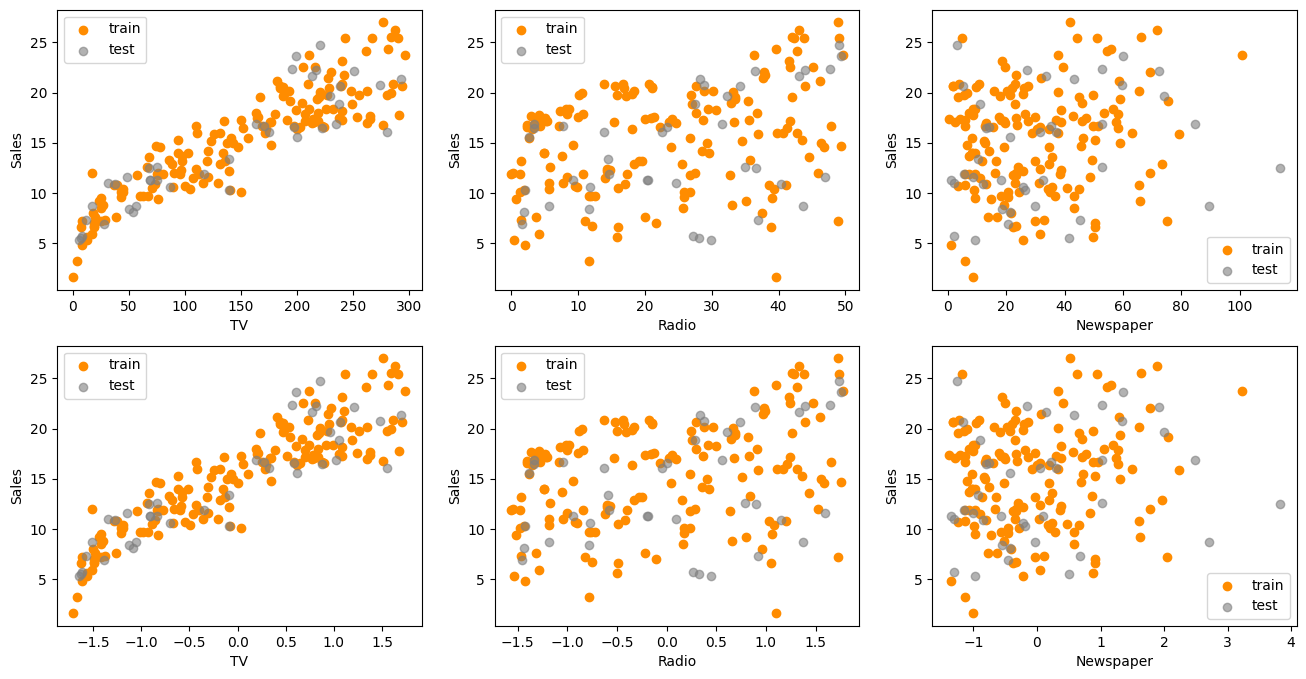

In [ ]:
plt.figure(figsize=(16,8))

def draw_plot_for_knn(X_train, X_test, y_train, y_test, idx=0):
    for i in range(3):
        plt.subplot(2, 3, i+1+idx)
        plt.scatter(X_train.iloc[:, i], y_train, color='darkorange', label='train')
        plt.scatter(X_test.iloc[:, i], y_test, color='gray', alpha=0.6, label='test')
        plt.xlabel(X_train.columns[i])
        plt.ylabel(y_train.columns[0])
        plt.legend()

draw_plot_for_knn(X_train, X_test, y_train, y_test)
draw_plot_for_knn(X_train_norm, X_test_norm, y_train, y_test, idx=X_train.shape[1])

In [ ]:
import sklearn.metrics as skm
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

knn_norm = KNeighborsRegressor(n_neighbors=3)
knn_norm.fit(X_train, y_train)


def show_results_for_models(
    X_train,
    X_test_,
    y_train,
    y_test_,
    model,
    variant="None",):

    y_pred = model.predict(X_test_)
    rsc = model.score(X_test_, y_test_)
    mse = skm.mean_squared_error(y_test_, y_pred)
    mape = skm.mean_absolute_percentage_error(y_test_, y_pred)
    mae = skm.mean_absolute_error(y_test_, y_pred)
    return dict(variant=variant, MSE=mse, MAE=mae, MAPE=mape, RSC=rsc)

all_results = []
all_results.append(show_results_for_models(X_train, X_test, y_train, y_test, knn, variant='knn'))
all_results.append(show_results_for_models(X_train_norm, X_test_norm, y_train, y_test, knn, variant='knn_norm'))

pd.DataFrame(all_results)


,variant,MSE,MAE,MAPE,RSC
0,knn,3.362861,1.424167,0.104698,0.891173
1,knn_norm,128.845111,9.896667,0.629649,-3.169596


# Ex2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
ds_path = Path(path) / "bank.csv"

df_bank = pd.read_csv(ds_path)
df_bank.head()

100%|██████████| 142k/142k [00:00<00:00, 19.8MB/s]

Extracting files...


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df_bank.drop(columns=["deposit"]))
y = (df_bank["deposit"] == "yes").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]

In [ ]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as skm

def results_for_LogReg_with_custom_treshold(
    X_train,
    X_test_,
    y_train,
    y_test_,
    threshold,
    iters=1000,
    variant="None",):

    model = LogisticRegression(fit_intercept=True, max_iter=iters)
    model.fit(X_train, y_train.to_numpy())
    # print(variant, model.coef_)

    probs_for_yes = model.predict_proba(X_test_)[:, 1]
    y_pred = (probs_for_yes > threshold).astype(int)


    accuracy = skm.accuracy_score(y_test_, y_pred)
    precision = skm.precision_score(y_test_, y_pred)
    recall = skm.recall_score(y_test_, y_pred)
    f1 = skm.f1_score(y_test_, y_pred)
    roc_auc = skm.roc_auc_score(y_test_, probs_for_yes)

    return dict(variant=variant,
                Accuracy=accuracy,
                Precision_Score=precision,
                Recall_Score=recall,
                F1_Score=f1,
                ROC=roc_auc)

all_results = []
for t in thresholds:
    all_results.append(results_for_LogReg_with_custom_treshold(
        X_train,
        X_test,
        y_train,
        y_test,
        threshold=t,
        variant=f"Logisitic Regression with threshold: {t}"
    ))
pd.DataFrame(all_results)

/home/mikol/Projects/Studia/7_sem/Machine_Learning-v2/.venv/lib64/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/mikol/Projects/Studia/7_sem/Machine_Learning-v2/.venv/lib64/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale

,variant,Accuracy,Precision_Score,Recall_Score,F1_Score,ROC
0,Logisitic Regression with threshold: 0.1,0.644872,0.574134,0.994377,0.727959,0.89563
1,Logisitic Regression with threshold: 0.25,0.789521,0.708014,0.952202,0.812150,0.89563
2,Logisitic Regression with threshold: 0.5,0.807434,0.811949,0.776945,0.794061,0.89563
3,Logisitic Regression with threshold: 0.75,0.733094,0.870866,0.518276,0.649824,0.89563
4,Logisitic Regression with threshold: 0.9,0.665920,0.914729,0.331771,0.486933,0.89563


In [8]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as skm

def calculate_tpr_fpr_for_threshold(
    X_train,
    X_test_,
    y_train,
    y_test_,
    threshold,
    iters=100
):
    if threshold % 0.1 == 0:
        print(f"Calculating: {threshold * 100}%")

    model = LogisticRegression(fit_intercept=True, max_iter=iters)
    model.fit(X_train, y_train)

    probs_with_yes = model.predict_proba(X_test_)[:, 1]
    y_pred = (probs_with_yes > threshold).astype(int)

    tn, fp, fn, tp = skm.confusion_matrix(y_test_, y_pred).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return tpr, fpr

thresholds = np.linspace(0, 1, 101)

tprs, fprs = [], []

for t in thresholds:
    tpr, fpr = calculate_tpr_fpr_for_threshold(X_train, X_test, y_train, y_test, t)
    tprs.append(tpr)
    fprs.append(fpr)
tprs, fprs = np.array(tprs), np.array(fprs)


Calculating: 0.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 10.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 20.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 40.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 80.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

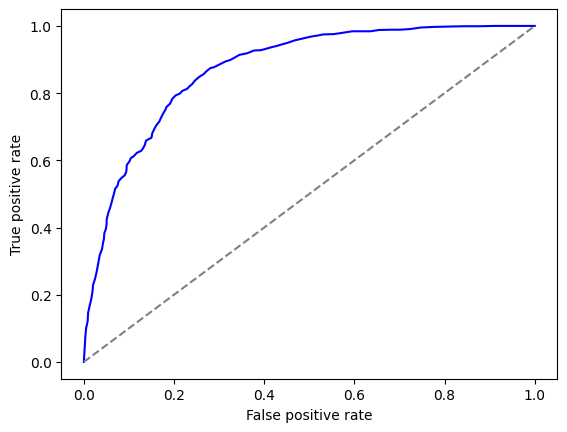

In [9]:
roc = plt.plot(fprs, tprs)
plt.setp(roc, color='b')
mid_line = plt.plot(thresholds, thresholds)
plt.setp(mid_line, color='gray', linestyle='--')

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as skm

def calculate_tpr_fpr_for_threshold(
    X_train,
    X_test_,
    y_train,
    y_test_,
    threshold,
    iters=100
):
    cost_fp, cost_fn = 10, 3
    if threshold % 0.1 == 0:
        print(f"Calculating: {threshold * 100}%")

    model = LogisticRegression(fit_intercept=True, max_iter=iters)
    model.fit(X_train, y_train)

    probs_with_yes = model.predict_proba(X_test_)[:, 1]
    y_pred = (probs_with_yes > threshold).astype(int)

    tn, fp, fn, tp = skm.confusion_matrix(y_test_, y_pred).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    cost = fp * cost_fp + fn * cost_fn
    return cost

thresholds = np.linspace(0, 1, 101)

costs = []

for t in thresholds:
    c = calculate_tpr_fpr_for_threshold(X_train, X_test, y_train, y_test, t)
    costs.append(c)

costs = np.array(costs)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold:", optimal_threshold)

Calculating: 0.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 10.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 20.0%


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Calculating: 80.0%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Optimal threshold: 0.74


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
coefs = pd.Series(model.coef_[0], index=X_train.columns)
top2 = coefs.abs().sort_values(ascending=False).head(2).index.tolist()
print("Best coeficients:", top2)

Best coeficients: ['poutcome_success', 'contact_unknown']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
X_train_top2 = X_train[top2]
X_test_top2 = X_test[top2]+

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_top2, y_train)

LogisticRegression(max_iter=1000)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


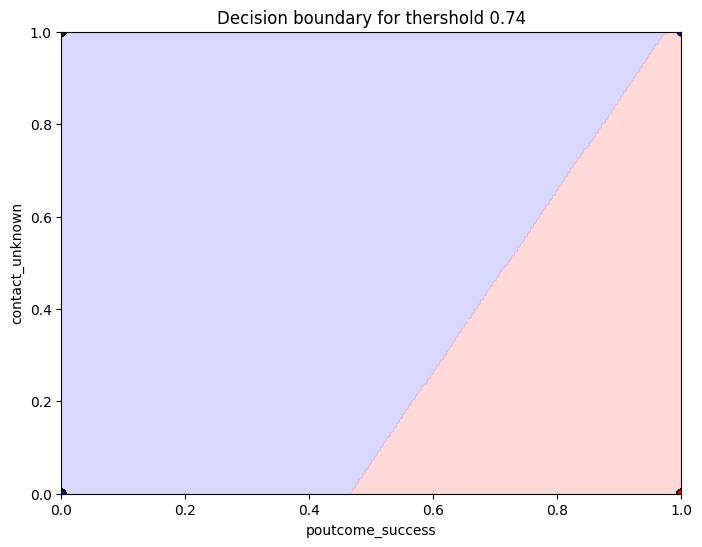

In [31]:
import matplotlib.pyplot as plt
import numpy as np

x_min, x_max = X_test_top2.iloc[:, 0].min(), X_test_top2.iloc[:, 0].max()
y_min, y_max = X_test_top2.iloc[:, 1].min(), X_test_top2.iloc[:, 1].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model2.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, probs > optimal_threshold, alpha=0.3, cmap='bwr')
plt.scatter(X_test_top2.iloc[:, 0], X_test_top2.iloc[:, 1], c=y_test, cmap='bwr', edgecolor='k')
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.title(f'Decision boundary for thershold {optimal_threshold:.2f}')
plt.show()

# Ex4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path


# Download latest version
path = Path(kagglehub.dataset_download("uciml/adult-census-income"))

dataset_path = list(path.iterdir())[0]

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(dataset_path)
# df = df.replace('?', np.nan).dropna()

df['income'] = (df['income'] == '>50K').astype(int)

X, y = df.drop(columns=['income']), df['income']
X_one_hot = pd.get_dummies(X).astype(int)


X_train, X_test, y_train, y_test = train_test_split(X_one_hot, y, test_size=0.2, random_state=42)

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

logit = sm.Logit(y_train, X_train_const)
res = logit.fit(maxiter=100)
res.summary()

         Current function value: 0.314964
         Iterations: 100


/home/mikol/Projects/Studia/7_sem/Machine_Learning-v2/.venv/lib64/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 income   No. Observations:                26048
Model:                          Logit   Df Residuals:                    25949
Method:                           MLE   Df Model:                           98
Date:                Tue, 04 Nov 2025   Pseudo R-squ.:                  0.4308
Time:                        15:18:26   Log-Likelihood:                -8204.2
converged:                      False   LL-Null:                       -14415.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                       -10.1542        nan        nan        nan         nan         nan
age                                           0.0257      0.002     13.848      0.000       0.022       0.029
fnlwgt                                     8.125e-07   1.92e-07      4.227      0.000    4.36e-07    1.19e-06
education.num                                 0.3528        nan        nan        nan         nan         nan
capital.gain                                  0.0003   1.17e-05     27.392      0.000       0.000       0.000
capital.loss                                  0.0007   4.14e-05     16.246      0.000       0.001       0.001
hours.per.week                                0.0288      0.002     15.826      0.000       0.025       0.032
workclass_?                                  13.4844        nan        nan        nan         nan         nan
workclass_Federal-gov                         5.6442   3.72e+05   1.52e-05      1.000    -7.3e+05     7.3e+05
workclass_Local-gov                           4.9978   3.55e+05   1.41e-05      1.000   -6.95e+05    6.95e+05
workclass_Never-worked                      -19.9169   4.27e+07  -4.66e-07      1.000   -8.37e+07    8.37e+07
workclass_Private                             5.1516   3.87e+05   1.33e-05      1.000   -7.59e+05    7.59e+05
workclass_Self-emp-inc                        5.4155   2.96e+05   1.83e-05      1.000    -5.8e+05     5.8e+05
workclass_Self-emp-not-inc                    4.7258   2.55e+05   1.85e-05      1.000      -5e+05       5e+05
workclass_State-gov                           4.8326   2.79e+05   1.73e-05      1.000   -5.46e+05    5.46e+05
workclass_Without-pay                       -34.4892   2.19e+08  -1.58e-07      1.000   -4.29e+08    4.29e+08
education_10th                                0.4934        nan        nan        nan         nan         nan
education_11th                                0.2314        nan        nan        nan         nan         nan
education_12th                                0.3575        nan        nan        nan         nan         nan
education_1st-4th                             1.4013        nan        nan        nan         nan         nan
education_5th-6th                             1.0021        nan        nan        nan         nan         nan
education_7th-8th                             0.7143        nan        nan        nan         nan         nan
education_9th                                 0.3336        nan        nan        nan         nan         nan
education_Assoc-acdm                         -0.3272        nan        nan        nan         nan         nan
education_Assoc-voc                          -0.0262        nan        nan        nan         nan         nan
education_Bachelors                          -0.0892        nan        nan        nan         nan         nan
education_Doctorate                          -0.043